# PROC GPROJECTを用いたマッピングのための臨床試験施設座標投影

## エグゼクティブサマリー

臨床オペレーションチームは、複数施設からなる第III相治験の地理的な広がりを平面地図上に描画する必要がある。このノートブックは、米国内5つの地域ハブを中心に集まる治験施設の合成緯度・経度座標を生成し、**PROC GPROJECT**を用いて球面座標を3つの投影法（Albers正積図法、標準緯線をカスタム指定し地域をクリップしたLambert正角図法、米国本土を中心としたGnomonic図法）でデカルトX/Y値に変換することで、投影法とクリッピングの選択が施設マップにどう影響するかを示す。

## データソース

| データセット | 行数 | 主な変数 | 説明 |
|---------|------|---------------|-------------|
| `trial_sites` | 60（5ハブ×12施設） | `site_id`（$8のID）、`region`（$16）、`x`（経度、度、東経を正）、`y`（緯度、度）、`enroll`（登録被験者数）、`segment`（マップセグメントID） | `rand('normal')`によるジッターと`rand('poisson')`による登録人数を用い、米国内5つの地域ハブ（西部、中西部、北東部、南部、南東部）の周辺に散らばる合成の第III相臨床試験施設の位置 |

# PROC GPROJECTによる臨床試験施設座標の投影

地理的に分散した第III相治験をスポンサーが実施する場合、臨床オペレーショングループはしばしば、登録人数でサイズや色分けした、すべての治験責任医師施設を示す一枚の地図を求める。施設の位置は**経度・緯度のペア**として届くが、平面地図には**平面X/Y座標**が必要である。`PROC GPROJECT`はこの球面からデカルト座標への変換を行い、地図投影法を適用することで距離と面積が妥当に表現されるようにする。

このノートブックでは：

1. 米国内5つの地域ハブを中心に集まる合成の施設座標を生成する。
2. デフォルトの**Albers正積図法**を適用する。
3. カスタムの標準緯線を指定し、米国本土にクリップした**Lambert正角図法**を適用する。
4. `ASIS`で元の座標を保持しつつ、国の地理的中心を中心とした**Gnomonic図法**を適用する。

すべて自己完結しており、外部ファイルもネットワークも使用しない。

## ステップ1 — 合成の治験施設座標を生成する

再現性のため`call streaminit`で乱数生成器の種を指定し、5つの地域ハブ都市それぞれの周囲に12施設を配置する。経度は度単位で東経を正として格納し（西半球では負）、緯度も度単位で格納する。各行には登録人数と`segment`変数も含まれる（GPROJECTは投影を通じて座標以外の列を保持する）。

In [1]:
データ trial_sites;
    呼出 streaminit(20260531);
    長さ site_id $8 region $16;
    /* Five U.S. regional hub centers: longitude (east+), latitude */
    配列 clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    配列 clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    繰返 hub = 1 から 5;
        もし hub = 1 なら region = '西部';
        他 もし hub = 2 なら region = '中西部';
        他 もし hub = 3 なら region = '北東部';
        他 もし hub = 4 なら region = '南部';
        他 region = '南東部';
        繰返 s = 1 から 12;
            site_id = cats('S', PUT(hub, z1.), PUT(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* longitude, degrees */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* latitude,  degrees */
            enroll  = round(rand('poisson', 60));           /* enrolled subjects  */
            segment = 1;
            出力;
        終了;
    終了;
    削除 hub s;
実行;

処理 印刷 データ=trial_sites(obs=10) 見出;
    見出 site_id="施設ID" region="地域" x="経度" y="緯度" enroll="登録人数" segment="セグメント";
    表題 "合成臨床試験施設データのサンプル（未投影の経度・緯度）";
実行;


                                              合成臨床試験施設データのサンプル（未投影の経度・緯度）                                               

  Obs      施設ID      地域               経度             緯度          登録人数            セグメント
    1  S101      西部      -121.6437232216  37.7677668495            65                1
    2  S102      西部      -120.7384024716  37.5083287903            61                1
    3  S103      西部      -121.5133780284  37.8633933883            72                1
    4  S104      西部      -121.2086817368  38.7723343392            68                1
    5  S105      西部      -121.0499572297   37.175813806            54                1
    6  S106      西部      -124.0531899967   35.778231667            72                1
    7  S107      西部      -120.9370181032  39.0576714397            64                1
    8  S108      西部      -126.8495029747  36.6474680375            55                1
    9  S109      西部       -123.475989897  37.1427965254            56                1
   10  S


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## ステップ2 — デフォルトのAlbers正積図法投影

**Albers**正積円錐図法はGPROJECTの既定値であり、*相対的な面積*の保持が重要な国レベルの地図（例えば地域ごとの集患圏の大きさを比較する場合）に適した選択である。

座標が**度単位**かつ**東経を正**で格納されているため、`DEGREE`オプションと`EASTLONG`オプションを指定する。`ID`ステートメントは各単位を一意に識別する変数を指定し、投影された平面座標は`OUT=`データセットの`x`と`y`に書き戻される。

In [2]:
処理 GPROJECT データ=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
実行;

処理 印刷 データ=sites_albers(obs=10) 見出;
    見出 site_id="施設ID" region="地域" x="X座標（Albers）" y="Y座標（Albers）" enroll="登録人数" segment="セグメント";
    表題 "Albers正積図法投影後の治験施設（平面X/Y）";
実行;


                                              合成臨床試験施設データのサンプル（未投影の経度・緯度）                                               

                                               Albers正積図法投影後の治験施設（平面X/Y）                                                

  Obs      施設ID      地域          X座標（Albers）          Y座標（Albers）          登録人数            セグメント
    1  S101      西部             -0.346124731         0.0516986079            65                1
    2  S102      西部            -0.3353644139         0.0440400181            61                1
    3  S103      西部            -0.3439609675         0.0528501365            72                1
    4  S104      西部            -0.3357513354          0.067213083            68                1
    5  S105      西部            -0.3410170723         0.0394882801            54                1
    6  S106      西部            -0.3879364507         0.0273340733            72                1
    7  S107      西部            -0.3309127579         0.0711146305            


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## ステップ3 — カスタム標準緯線とクリッピングを用いたLambert正角図法投影

**Lambert正角**円錐図法は*形状と局所的な角度*を保持するため、ナビゲーション用途や方位を持つ地物の重ね合わせに適している。米国本土では北緯33度付近と北緯45度付近を標準緯線とするのが慣例であるため、`PARALLEL1=`と`PARALLEL2=`で明示的に指定する。

また、クリッピングオプション`LATMIN=`、`LATMAX=`、`LONGMIN=`、`LONGMAX=`を用いて地図を米国本土のウィンドウに制限する。この緯度・経度のボックスの外側にある施設は投影前に除外されるため、出力の観測数は入力より少なくなることがある。

In [3]:
処理 GPROJECT データ=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
実行;

処理 印刷 データ=sites_lambert(obs=10) 見出;
    見出 site_id="施設ID" region="地域" x="X座標（Lambert）" y="Y座標（Lambert）" enroll="登録人数" segment="セグメント";
    表題 "Lambert正角図法投影後の治験施設（米国本土でクリップ）";
実行;


                                               Albers正積図法投影後の治験施設（平面X/Y）                                                

                                             Lambert正角図法投影後の治験施設（米国本土でクリップ）                                             

  Obs      施設ID      地域          X座標（Lambert）          Y座標（Lambert）          登録人数            セグメント
    1  S101      西部             -0.3473024124          0.0279382533            65                1
    2  S102      西部             -0.3365626234          0.0201991247            61                1
    3  S103      西部             -0.3451238364          0.0290365995            72                1
    4  S104      西部             -0.3367881094          0.0430616123            68                1
    5  S105      西部             -0.3422656751          0.0158037156            54                1
    6  S106      西部             -0.3894389642          0.0046370991            72                1
    7  S107      西部             -0.3319086764          0.046827


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## ステップ4 — 国を中心としたGnomonic図法投影、元の座標も保持

**Gnomonic**方位図法はすべての大圏航路を直線として描画するため、施設間の最短経路について検討したい場合（例えばモニターの訪問ルートを計画する場合）に有用である。歪みは投影の極からの距離とともに大きくなるため、`POLELAT=39`と`POLELONG=-98`で極を米国本土の地理的中心に置く。

`ASIS`オプションはGPROJECTに対し、投影された値とあわせて元の未投影座標も保持するよう指示する。そのため出力データセットには平面の`X`/`Y`と元の`LONG`/`LAT`の両方が含まれ、どちらの座標空間にも登録人数などの指標を後から結合しやすくなる。

`PARMENTRY`ステートメントは、投影パラメータをkey=value形式の上書きとして与える代替手段として示されている。

In [4]:
処理 GPROJECT データ=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
実行;

処理 印刷 データ=sites_gnomon(obs=10) 見出;
    見出 site_id="施設ID" region="地域" x="X座標（Gnomonic）" y="Y座標（Gnomonic）"
          enroll="登録人数" segment="セグメント" long="経度（元）" lat="緯度（元）";
    表題 "Gnomonic図法投影後の治験施設（ASISで元のLONG/LATを保持）";
実行;


                                             Lambert正角図法投影後の治験施設（米国本土でクリップ）                                             

                                         Gnomonic図法投影後の治験施設（ASISで元のLONG/LATを保持）                                         

  Obs      施設ID      地域          X座標（Gnomonic）          Y座標（Gnomonic）          登録人数            セグメント            経度（元）            緯度（元）
    1  S101      西部              -0.3343477981           0.0213614461            65                1  -121.6437232216    37.7677668495
    2  S102      西部              -0.3221611694           0.0134152735            61                1  -120.7384024716    37.5083287903
    3  S103      西部              -0.3319480803           0.0225717184            72                1  -121.5133780284    37.8633933883
    4  S104      西部              -0.3230855797           0.0375741352            68                1  -121.2086817368    38.7723343392
    5  S105      西部              -0.3283677206           0.0086308769            


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## ステップ5 — 投影後の施設マップを描画する

投影を行う目的はまさに地図を描くことにある。Albersの`OUT=`データセットをそのまま**PROC SGPLOT**に渡し、平面`X`/`Y`をプロットして各マーカーを`region`で色分けする。投影が相対的な地理関係を保持しているため、5つのハブのクラスターはプロットの想定通りの位置に収まる——西部（West）は左側、北東部（Northeast）は右上、南部（South）と南東部（Southeast）は下側——エグゼクティブサマリーで述べた面積忠実なフットプリントを臨床オペレーションに提供する。

                                         Gnomonic図法投影後の治験施設（ASISで元のLONG/LATを保持）                                         




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


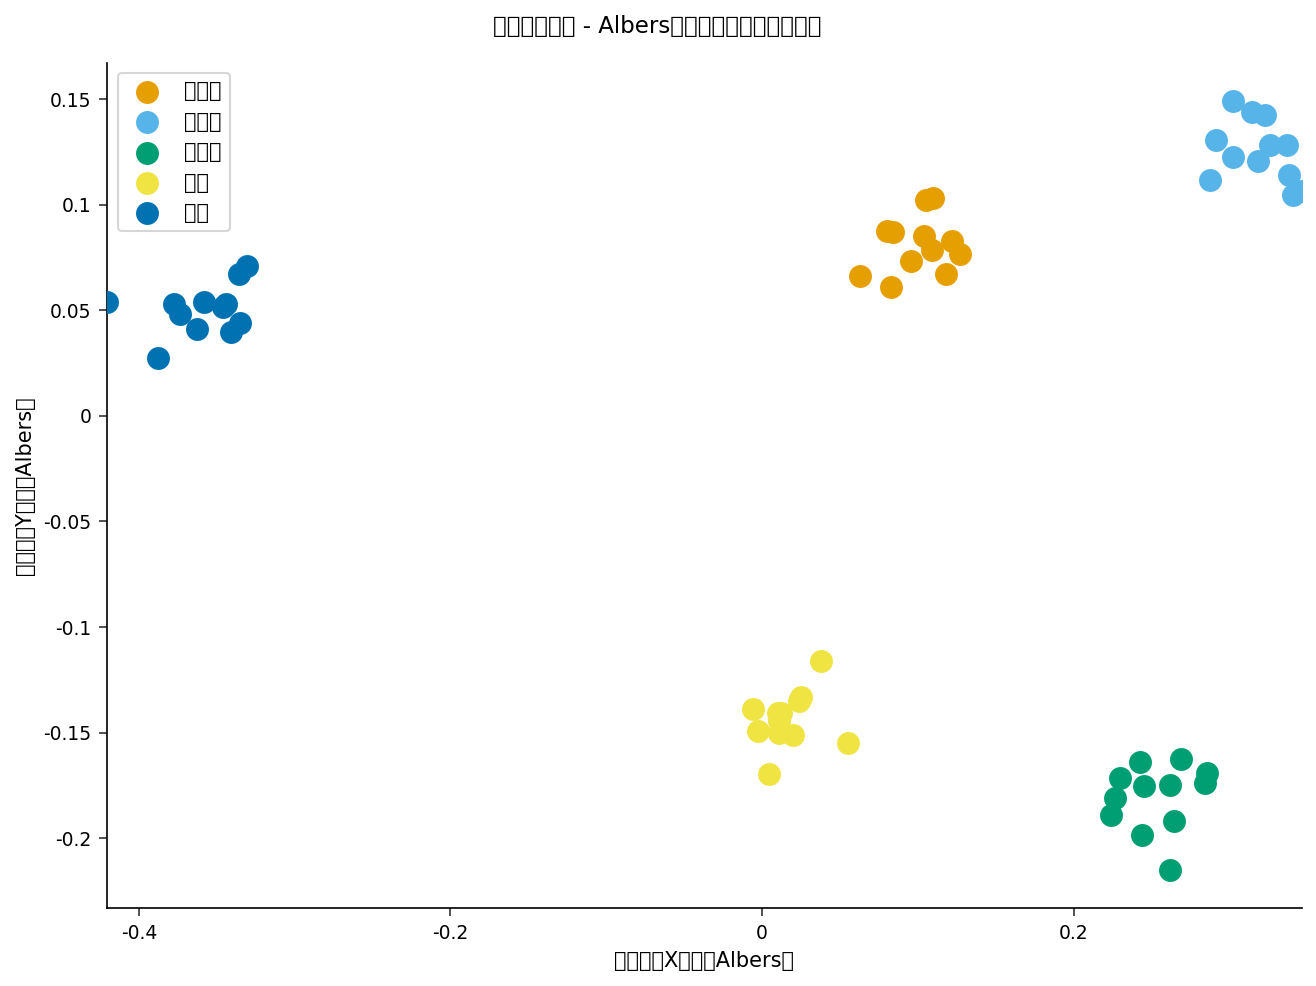

In [5]:
処理 SGPLOT データ=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS 見出="投影後のX座標（Albers）";
    YAXIS 見出="投影後のY座標（Albers）";
    表題 "臨床試験施設 - Albers投影後のフットプリント";
実行;


## 結果の解釈

- **Albers（ステップ2）**は60施設すべてを相対的な面積を保持したまま平面座標に変換した——西部、中西部、北東部、南部、南東部の各クラスターは空間的な広がりの比率を保っており、面積忠実な登録人数ヒートマップの正しい基盤となる。
- **クリッピング付きLambert（ステップ3）**は局所的な形状を保持し、`LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX`のウィンドウを適用することで米国本土の外に散らばった合成施設を除外した——ここでは件数が60から58に減少しており、そのままでは地図を歪めていたであろう2つの範囲外座標が投影前に取り除かれたことを意味する。
- **`ASIS`付きGnomonic（ステップ4）**は投影の中心を国の内陸部に置き、`ASIS`のおかげで投影された`X`/`Y`と元の`LONG`/`LAT`の両方を含むデータセットを生成した。大圏航路は直線として現れるため、この地図上の直線距離は施設間の真の最短経路に近似する。
- **描画されたフットプリント（ステップ5）**は投影が正しく機能したことを裏付ける：Albersの`X`/`Y`をregion別にプロットすると、5つのハブのクラスターが平面上の想定通りの位置に収まり、エグゼクティブサマリーで約束した面積忠実な施設マップが得られる。

**臨床オペレーションへの要点：** 投影法の選択は見た目だけの問題ではない。面積忠実な登録密度には**Albers**を、地域クリッピング付きの形状忠実な重ね合わせには**Lambert**を、施設間の移動距離が分析を左右する場合には**Gnomonic**を選ぶ。ステップ5が示す通り、投影済みの`OUT=`データセットはそのままPROC SGPLOT（またはPROC GMAP）に渡して最終的な施設マップを描画できる。